In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization,
    Flatten, Dense, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)

print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {len(tf.config.list_physical_devices('GPU')) > 0}")



TensorFlow : 2.21.0
GPU        : False


In [2]:
# Charger MNIST
(X_train, y_train), (X_test, y_test) = \
    tf.keras.datasets.mnist.load_data()

########################### DIFFERENCE CLEE vs MLP ##########################
# MLP : aplatir 28x28 → 784 (perd la structure spatiale)
# CNN : garder 28x28x1 (conserve la structure spatiale !)

# Normaliser + ajouter dimension canal
X_train_cnn = X_train.astype('float32') / 255.0
X_test_cnn  = X_test.astype('float32')  / 255.0

X_train_cnn = X_train_cnn.reshape(-1, 28, 28, 1)  #  (N, H, W, C)
X_test_cnn  = X_test_cnn.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train_ohe = tf.keras.utils.to_categorical(y_train, 10)
y_test_ohe  = tf.keras.utils.to_categorical(y_test,  10)

print("APRES PREPROCESSING CNN :")
print(f"  X_train : {X_train_cnn.shape}")  # (60000, 28, 28, 1)
print(f"  X_test  : {X_test_cnn.shape}")
print()
print("COMPARAISON PREPROCESSING :")
print(f"  MLP : (60000, 784)    <- pixels aplatis")
print(f"  CNN : (60000, 28, 28, 1) <- structure spatiale conservee")

APRES PREPROCESSING CNN :
  X_train : (60000, 28, 28, 1)
  X_test  : (10000, 28, 28, 1)

COMPARAISON PREPROCESSING :
  MLP : (60000, 784)    <- pixels aplatis
  CNN : (60000, 28, 28, 1) <- structure spatiale conservee


In [3]:
############ Architecture CNN ##############
#
# Input : 28x28x1 (image en niveau de gris)
#
# [Conv2D(32, 3x3) + BatchNormalisation + ReLU] x 2 + maxPool2D + dropout
#
# ==> Image 14x14x32
#
# [Conv2D(64, 3x3) + BatchNormalisation + ReLU] x 2 + maxPool2D + dropout
#
# ==> Image 7x7x64
#
# Flatten => Dense(128) => Dropout => Dense(10, Softmax)

model_cnn = Sequential([
    ###### BLOC 1 : Detecter les bords er contours ##########
    Conv2D(32,(3,3), padding='same', input_shape=(28,28,1)),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    Conv2D(32,(3,3),padding='same'),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    MaxPooling2D(2, 2),     # 28x28 -> 14x14
    Dropout(0.25),

    ###### BLOC 2 : Detecter les formes complexes #######
    Conv2D(64,(3,3), padding='same'),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    Conv2D(64,(3,3), padding='same'),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    MaxPooling2D(2,2),  # 14x14 -> 7x7
    Dropout(0.25),

    ###### CLASSIFIEUR #######
    Flatten(),  # 7x7x64 = 3136
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10,activation='softmax')
    
],name = "CNN_MNIST")

model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

# Comparer les parametres
mlp_params = 571018
cnn_params  = model_cnn.count_params()
print(f"\nMLP params : {mlp_params:,}")
print(f"CNN params : {cnn_params:,}")
print(f"Le CNN a {mlp_params/cnn_params:.1f}x moins de params que le MLP !")

Model: "CNN_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 28, 28, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 28, 28, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 28, 28, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 14, 14, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 14, 14, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 14, 14, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │              

 Total params: 469,098 (1.79 MB)

 Trainable params: 468,458 (1.79 MB)

 Non-trainable params: 640 (2.50 KB)


MLP params : 571,018
CNN params : 469,098
Le CNN a 1.2x moins de params que le MLP !


In [4]:
# Entrainement

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("Debut entrainement CNN Keras...")
print("="*50)

history_cnn = model_cnn.fit(
    X_train_cnn, y_train_ohe,
    validation_split=0.1,
    epochs=50,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

print("\n Entrainement termine !")
print(f"   Epochs          : {len(history_cnn.history['loss'])}")
print(f"   Meilleure val_acc : {max(history_cnn.history['val_accuracy']):.4f}")

Debut entrainement CNN Keras...
Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 105s 237ms/step - accuracy: 0.9315 - loss: 0.2304 - val_accuracy: 0.8398 - val_loss: 0.5099 - learning_rate: 0.0010
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 142s 238ms/step - accuracy: 0.9768 - loss: 0.0756 - val_accuracy: 0.9838 - val_loss: 0.0563 - learning_rate: 0.0010
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 101s 240ms/step - accuracy: 0.9820 - loss: 0.0591 - val_accuracy: 0.9900 - val_loss: 0.0317 - learning_rate: 0.0010
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 134s 221ms/step - accuracy: 0.9859 - loss: 0.0462 - val_accuracy: 0.9905 - val_loss: 0.0312 - learning_rate: 0.0010
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 101s 240ms/step - accuracy: 0.9870 - loss: 0.0417 - val_accuracy: 0.9938 - val_loss: 0.0232 - learning_rate: 0.0010
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 140s 234ms/step - accuracy: 0.9882 - loss: 0.0377 - val_accuracy: 0.9908 - val_loss: 0.0329 - learning_rate: 0.0010
Epoch 7/50
422/422 ━━━━━━━━━━━━━

In [5]:
# Evaluation sur test set
test_loss, test_acc = model_cnn.evaluate(
    X_test_cnn, y_test_ohe, verbose=0)

y_pred_proba = model_cnn.predict(X_test_cnn, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)

print(f"Test Accuracy CNN : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print()

# Rapport de classification
print(classification_report(
    y_test, y_pred,
    target_names=[str(i) for i in range(10)],
    digits=4
))

Test Accuracy CNN : 0.9961  (99.61%)

              precision    recall  f1-score   support

           0     0.9939    0.9990    0.9964       980
           1     0.9965    0.9982    0.9974      1135
           2     0.9990    0.9952    0.9971      1032
           3     0.9951    0.9970    0.9960      1010
           4     0.9969    0.9959    0.9964       982
           5     0.9966    0.9955    0.9961       892
           6     0.9989    0.9916    0.9953       958
           7     0.9932    0.9971    0.9951      1028
           8     0.9969    0.9938    0.9954       974
           9     0.9941    0.9970    0.9955      1009

    accuracy                         0.9961     10000
   macro avg     0.9961    0.9960    0.9961     10000
weighted avg     0.9961    0.9961    0.9961     10000



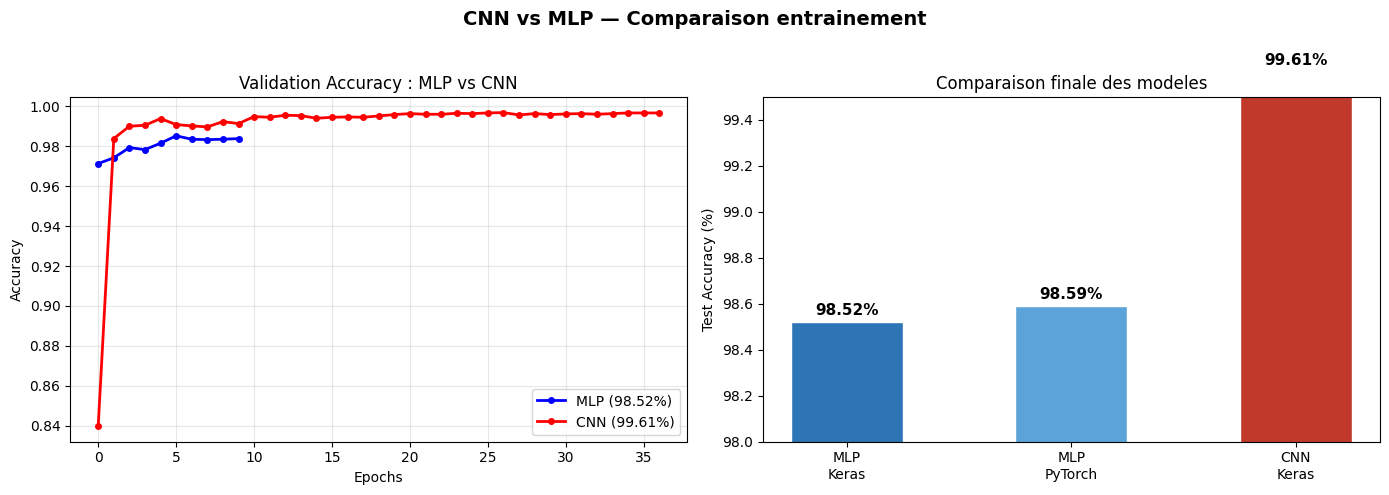

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("CNN vs MLP — Comparaison entrainement",
             fontsize=14, fontweight='bold')

####### Accuracy comparison #########
mlp_val_acc = [0.9713, 0.9742, 0.9793, 0.9783, 0.9815,
               0.9852, 0.9835, 0.9833, 0.9835, 0.9838]  # history MLP

cnn_val_acc = history_cnn.history['val_accuracy']

axes[0].plot(mlp_val_acc[:len(cnn_val_acc)],
             'b-o', markersize=4, label='MLP (98.52%)', lw=2)
axes[0].plot(cnn_val_acc,
             'r-o', markersize=4, label=f'CNN ({test_acc*100:.2f}%)', lw=2)
axes[0].set_title("Validation Accuracy : MLP vs CNN")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

####### Barplot comparaison finale #######
models    = ['MLP\nKeras', 'MLP\nPyTorch', 'CNN\nKeras']
accs      = [98.52, 98.59, test_acc*100]
colors    = ['#2E75B6', '#5BA3D9', '#C0392B']

bars = axes[1].bar(models, accs, color=colors, edgecolor='white', width=0.5)
axes[1].set_ylim(98.0, 99.5)
axes[1].set_title("Comparaison finale des modeles")
axes[1].set_ylabel("Test Accuracy (%)")

for bar, acc in zip(bars, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.03,
                 f'{acc:.2f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../assets/mlp_vs_cnn_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

Image originale  : (1, 28, 28, 1)
Feature maps     : (1, 28, 28, 32)
Chiffre          : 7


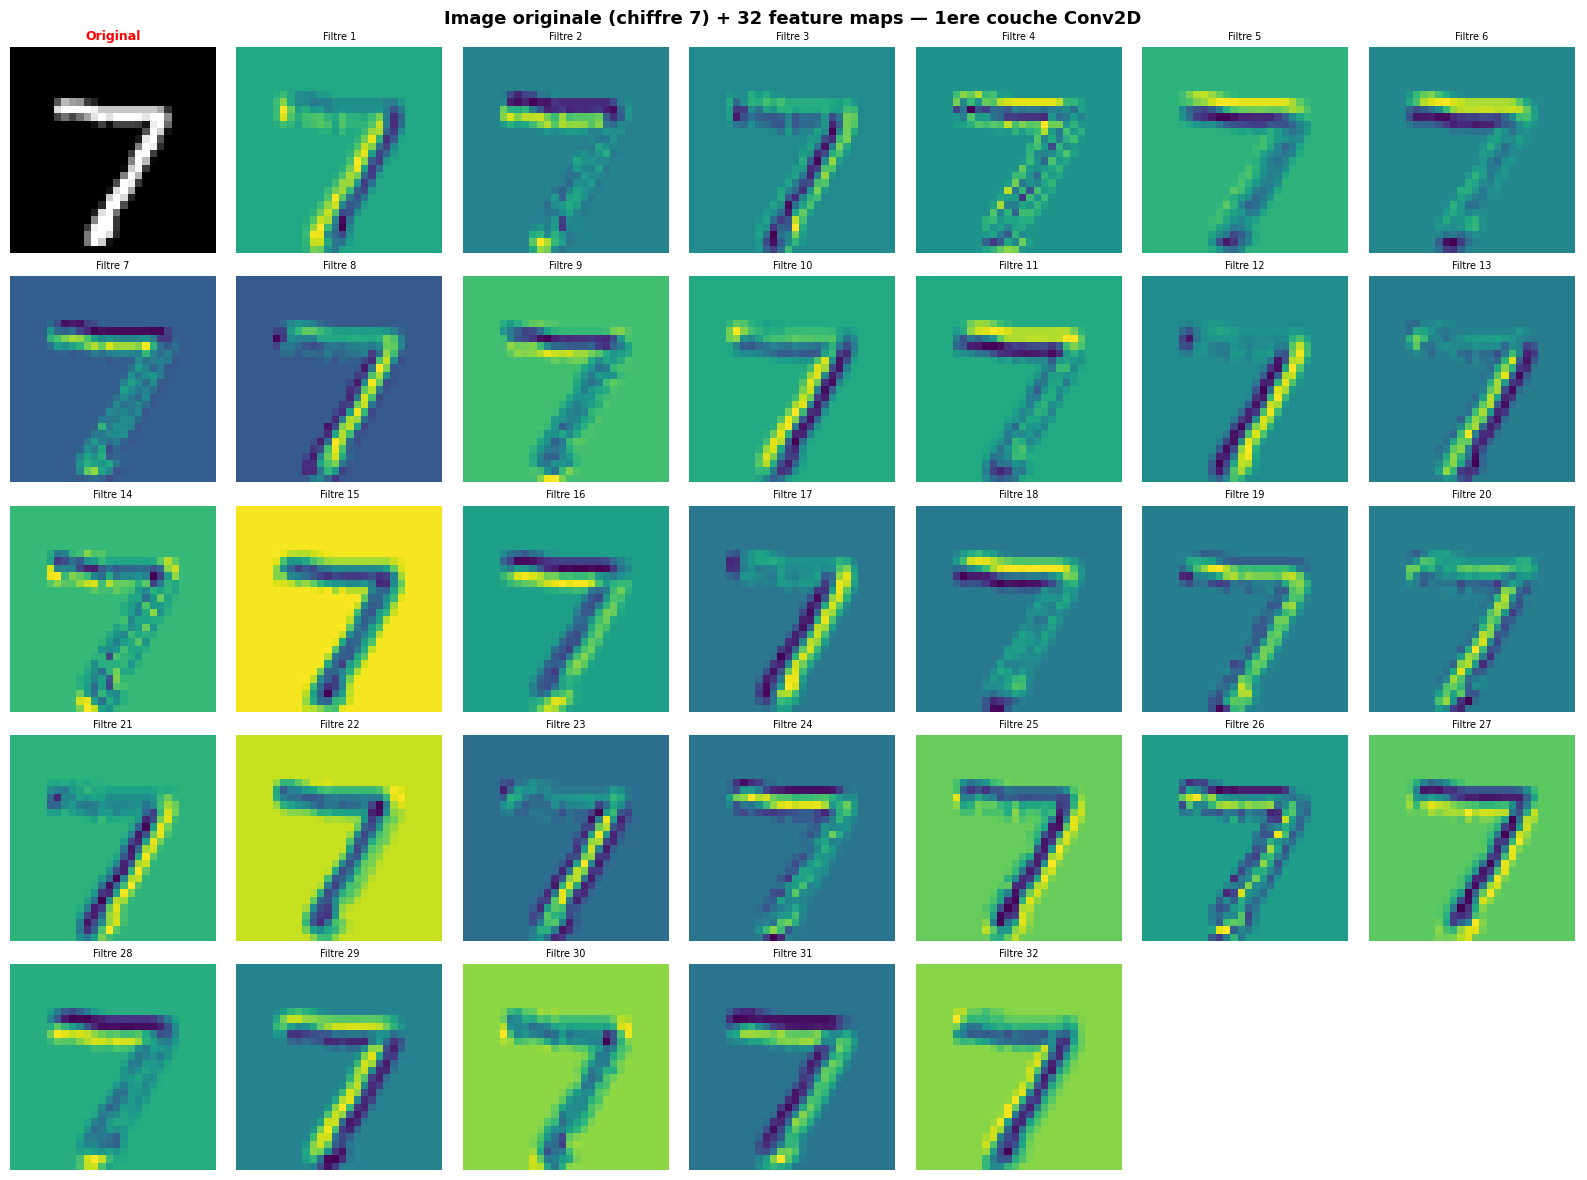


Observations :
  -> Chaque filtre detecte un pattern different
  -> Bords horizontaux, verticaux, diagonaux
  -> Zones sombres et zones claires
  -> C'est ce qui rend le CNN puissant sur les images


In [8]:
############ Feature maps avec Keras 3 ##################
# On utilise un sous-modele fonctionnel pour extraire les activations

inputs      = tf.keras.Input(shape=(28, 28, 1))
x           = inputs
for layer in model_cnn.layers:
    x = layer(x)
    if layer.name == model_cnn.layers[0].name:
        first_conv_output = x
        break

feature_extractor = tf.keras.Model(inputs=inputs,
                                   outputs=first_conv_output)

# Prendre une image test
sample_img  = X_test_cnn[0:1]
feature_maps = feature_extractor.predict(sample_img, verbose=0)

print(f"Image originale  : {sample_img.shape}")
print(f"Feature maps     : {feature_maps.shape}")
print(f"Chiffre          : {y_test[0]}")

# Afficher image originale + 32 feature maps
fig, axes = plt.subplots(5, 7, figsize=(16, 12))
fig.suptitle(
    f"Image originale (chiffre {y_test[0]}) + "
    f"32 feature maps — 1ere couche Conv2D",
    fontsize=13, fontweight='bold'
)

# Image originale (premiere case)
axes[0, 0].imshow(X_test[0], cmap='gray')
axes[0, 0].set_title("Original", fontsize=9, color='red', fontweight='bold')
axes[0, 0].axis('off')

# 32 feature maps
for i in range(32):
    row = (i + 1) // 7
    col = (i + 1) % 7
    if row < 5:
        axes[row, col].imshow(feature_maps[0, :, :, i], cmap='viridis')
        axes[row, col].set_title(f"Filtre {i+1}", fontsize=7)
        axes[row, col].axis('off')

# Cacher les cases vides
for i in range(33, 35):
    row = i // 7
    col = i % 7
    if row < 5:
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('../assets/feature_maps.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nObservations :")
print("  -> Chaque filtre detecte un pattern different")
print("  -> Bords horizontaux, verticaux, diagonaux")
print("  -> Zones sombres et zones claires")
print("  -> C'est ce qui rend le CNN puissant sur les images")

In [9]:
model_cnn.save('../models/cnn_keras_mnist.keras')

print("="*55)
print("RESUME FINAL — CNN KERAS MNIST")
print("="*55)
print(f"  Architecture  : Conv32 → Conv32 → Pool → "
      f"Conv64 → Conv64 → Pool → Dense128 → Dense10")
print(f"  Parametres    : {model_cnn.count_params():,}")
print(f"  Epochs        : {len(history_cnn.history['loss'])}")
print(f"  Val Accuracy  : {max(history_cnn.history['val_accuracy']):.4f}")
print(f"  Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print()
print("COMPARAISON COMPLETE :")
print(f"  MLP Keras   : 98.52%  | 571,018 params")
print(f"  MLP PyTorch : 98.59%  | 569,226 params")
print(f"  CNN Keras   : {test_acc*100:.2f}%  | "
      f"{model_cnn.count_params():,} params")
print()
print("-> CNN plus performant avec MOINS de parametres !")
print("-> Preuve que la structure convolutive est efficace")

RESUME FINAL — CNN KERAS MNIST
  Architecture  : Conv32 → Conv32 → Pool → Conv64 → Conv64 → Pool → Dense128 → Dense10
  Parametres    : 469,098
  Epochs        : 37
  Val Accuracy  : 0.9968
  Test Accuracy : 0.9961  (99.61%)

COMPARAISON COMPLETE :
  MLP Keras   : 98.52%  | 571,018 params
  MLP PyTorch : 98.59%  | 569,226 params
  CNN Keras   : 99.61%  | 469,098 params

-> CNN plus performant avec MOINS de parametres !
-> Preuve que la structure convolutive est efficace
